# Model 2: Random Forest 
In this notebook, we will run a random forest classifier (bagging) model to predict:
1. Layer 1: If a flight is delayed (0: not delayed, 1: delayed by 15 mins or more)
2. Layer 2: For delayed flights only, if the delay is minor ( between 15-45 minutes) or major (> 45 minutes)

** Note: It is important to upload the 4 parquets from the df_final_clean.parquet folder in the assignment repository to your GCS cluster in the Jupyter interface, for the code to run. 
If you are running this notebook in Google Collab, you must upload the data to your Google Drive. 


## Outline 
1. Imports & Spark session

2. Load data

3. Create layers + class weights

4. Assumptions
           
           - Null check
           - Zero variance check
           - Correlation check (distance vs distance_group)
           - Outlier check
           - Sample size check

5. Hyperparameter tuning 
           
           - CrossValidator on sample
           - Refit best params on full data

6. Train final RF models with best params (full data)
           

7. Evaluation metrics
           
           - evaluate_model() for all 3 models
           - Results table
           - Save results_rf.csv

8. Confusion matrices
  
9. Feature importance

10. End-to-end two-layer prediction
           
           - Predict layer 1 on test
           - Filter predicted delayed
           - Run layer 2 on predicted delayed
           - Print summary counts

11. Save models
          
12. Scalability metrics
           
           - Measure prediction time at 25/50/75/100% of test set
           - Record partition count
           - Record data size
13. Visualisations
           
           - Feature importance bar charts
           - Confusion matrix heatmaps
           - ROC curves
           - Scalability plot


In [16]:
# 1. Imports & Spark session (GCP Version)
import time
import pandas as pd
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, isnan, stddev, percentile_approx
from pyspark.sql.functions import min as spark_min, max as spark_max
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder.appName("ST446-RF").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark version: {spark.version}")
print("Spark session ready.")

Spark version: 3.5.3
Spark session ready.


In [17]:
# GCP VERSION

# 2. Loading data (feature file) 
df = spark.read.parquet("gs://dataproc-staging-europe-west2-896508268572-4p80aydm/notebooks/jupyter/*.parquet")
print(f"Total rows: {df.count():,}")
print(f"Columns: {df.columns}")

Total rows: 3,480,548
Columns: ['features', 'year', 'delay_class', 'is_late', 'delay_severity']


## 3. Create Layers + Class Weights

In [18]:
# 3. Create Layers + Class Weights

from pyspark.sql.functions import col, when

# Time-based split: 2019-2021 train, 2022 test
train = df.filter(col("year") <= 2021)
test  = df.filter(col("year") == 2022)
print(f"Train rows: {train.count():,}")
print(f"Test rows:  {test.count():,}")
print(f"Train/test split: {100*train.count()/df.count():.1f}% / {100*test.count()/df.count():.1f}%")

# Layer 1 class balance
print("\nLayer 1 class distribution (train):")
train.groupBy("is_late").count().orderBy("is_late").show()

# Class weights from training set
class_counts = train.groupBy("is_late").count().toPandas()
total     = class_counts["count"].sum()
n_classes = 2
class_counts["weight"] = total / (n_classes * class_counts["count"])
print("Class weights (Layer 1):")
print(class_counts.to_string(index=False))
weight_map = dict(zip(class_counts["is_late"], class_counts["weight"]))

# Add weight column
train_weighted = train.withColumn("class_weight",
    when(col("is_late") == 0, weight_map[0]).otherwise(weight_map[1]))
test_weighted = test.withColumn("class_weight",
    when(col("is_late") == 0, weight_map[0]).otherwise(weight_map[1]))

# Layer 2: delayed flights only
train_l2 = train.filter(col("is_late") == 1)
test_l2  = test.filter(col("is_late") == 1)
print(f"\nLayer 2 train rows: {train_l2.count():,}")
print(f"Layer 2 test rows:  {test_l2.count():,}")
print("\nLayer 2 train class distribution:")
train_l2.groupBy("delay_severity").count().orderBy("delay_severity").show()

Train rows: 2,784,642
Test rows:  695,906
Train/test split: 80.0% / 20.0%

Layer 1 class distribution (train):
+-------+-------+
|is_late|  count|
+-------+-------+
|      0|2362440|
|      1| 422202|
+-------+-------+

Class weights (Layer 1):
 is_late   count   weight
       1  422202 3.297760
       0 2362440 0.589357

Layer 2 train rows: 422,202
Layer 2 test rows:  125,309

Layer 2 train class distribution:
+--------------+------+
|delay_severity| count|
+--------------+------+
|             0|216893|
|             1|205309|
+--------------+------+



## 4. RF Assumptions:
1. Zero Variance among features
2. No multicollinearity
3. Sufficient Sample size per class
4. No extreme Outliers
5. No missing values


In [6]:
# Cell 4 — Assumption checks
from pyspark.sql.functions import col, when, count
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import min as spark_min, max as spark_max, percentile_approx

print("=" * 45)
print("ASSUMPTION CHECKS")
print("=" * 45)

# Check Null Values
print("\n1. Null check:")
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in ["year", "is_late", "delay_severity", "features"]
]).show()

# Feautre Vector Size
print("2. Feature vector:")
feature_size = len(df.first()["features"])
print(f"   Size: {feature_size} features")
print(f"   Encoding: StringIndexer + OneHotEncoder for carrier_id, origin, dest")
print(f"   Numeric as-is: dep_hour, day_of_week, month, distance, distance_group")
print(f"   year excluded (COVID-era generalisation concern)")

# Sample Size
print("\n3. Sample size check:")
min_samples_needed = 100 * 10
print(f"   Min recommended (10 x numTrees=100): {min_samples_needed:,}")
print(f"   Layer 1 minority class (delayed):    {train.filter(col('is_late')==1).count():,}")
print(f"   Layer 2 minority class:              {train_l2.filter(col('delay_severity')==1).count():,}")

# Balance Tests
print("\n4. Class balance:")
total_train = train.count()
print("   Layer 1:")
train.groupBy("is_late").count() \
    .withColumn("pct", (col("count") / total_train * 100).cast("decimal(5,2)")) \
    .orderBy("is_late").show()

total_l2 = train_l2.count()
print("   Layer 2:")
train_l2.groupBy("delay_severity").count() \
    .withColumn("pct", (col("count") / total_l2 * 100).cast("decimal(5,2)")) \
    .orderBy("delay_severity").show()

# Outliers
print("5. Feature vector value range check:")
df.select(
    vector_to_array("features").alias("f")
).selectExpr(
    "aggregate(f, 0D, (acc, x) -> greatest(acc, x)) as max_val",
    "aggregate(f, 1e10, (acc, x) -> least(acc, x)) as min_val"
).show()


ASSUMPTION CHECKS

1. Null check:
+----+-------+--------------+--------+
|year|is_late|delay_severity|features|
+----+-------+--------------+--------+
|   0|      0|             0|       0|
+----+-------+--------------+--------+

2. Feature vector:
   Size: 89 features
   Encoding: StringIndexer + OneHotEncoder for carrier_id, origin, dest
   Numeric as-is: dep_hour, day_of_week, month, distance, distance_group
   year excluded (COVID-era generalisation concern)

3. Sample size check:
   Min recommended (10 x numTrees=100): 1,000
   Layer 1 minority class (delayed):    422,202
   Layer 2 minority class:              205,309

4. Class balance:
   Layer 1:
+-------+-------+-----+
|is_late|  count|  pct|
+-------+-------+-----+
|      0|2362440|84.84|
|      1| 422202|15.16|
+-------+-------+-----+

   Layer 2:
+--------------+------+-----+
|delay_severity| count|  pct|
+--------------+------+-----+
|             0|216893|51.37|
|             1|205309|48.63|
+--------------+------+-----+


In [5]:
print(f"Feature vector size: {len(df.first()['features'])}")

Feature vector size: 89


All the assumptions for Random Forest are met, therefore, we can proceed to running the model. 

Pre-training assumption checks confirmed the dataset is suitable for Random Forest:

- No missing values were detected across any column including the feature vector, target variables, and year. The dataset is complete with 3,480,548 rows.

- The feature vector contains 89 dimensions, constructed from FeatureHasher applied to the three categorical variables (carrier_id, origin, dest), with five numeric features (dep_hour, day_of_week, month, distance, distance_group) appended directly. 

- The high dimensionality is expected given one-hot encoding of origin across approximately 200 airports. Random Forest is well-suited to this as it randomly samples a subset of features (√89 ≈ 9) at each split, mitigating the curse of dimensionality.

- Feature vector values range from 0 to a maximum of 1,199 (distance-related features), with a minimum of 0 across all features. The OHE columns are binary (0/1) and the numeric features show no evidence of pathological outliers, the maximum distance of 1,199 corresponds to legitimate long-haul domestic routes.

- Sample sizes far exceed the recommended minimum of 1,000 (10 × numTrees), with 422,202 delayed flights in Layer 1 and 205,309 major delay flights in Layer 2.

- Layer 1 confirms the expected class imbalance (84.84% on-time vs 15.16% delayed), motivating the use of class weighting. Layer 2 is well-balanced (51.37% minor vs 48.63% major), requiring no resampling.

In [67]:
train_weighted_sample.columns

['features',
 'year',
 'delay_class',
 'is_late',
 'delay_severity',
 'class_weight']

# 5. Hyperparameter Tuning

In [8]:
# Layer 1:
import time
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

print("=" * 45)
print("HYPERPARAMETER TUNING")
print("=" * 45)

# Layer 1 Tuning
train_weighted_sample, _ = train_weighted.randomSplit([0.3, 0.7], seed=42)
print(f"\nLayer 1 tuning sample size: {train_weighted_sample.count():,}")

rf_tune_l1 = RandomForestClassifier(
    featuresCol="features",
    labelCol="is_late",
    weightCol="class_weight",
    maxBins=300,
    seed=42
)

paramGrid_l1 = ParamGridBuilder() \
    .addGrid(rf_tune_l1.numTrees, [50, 100]) \
    .addGrid(rf_tune_l1.maxDepth, [5, 10]) \
    .build()

evaluator_l1 = BinaryClassificationEvaluator(
    labelCol="is_late",
    metricName="areaUnderROC"
)

cv_l1 = CrossValidator(
    estimator=rf_tune_l1,
    estimatorParamMaps=paramGrid_l1,
    evaluator=evaluator_l1,
    numFolds=2,
    seed=42
)

print("Tuning Layer 1 RF (4 combos x 2 folds = 8 fits on 30% sample)...")
t0 = time.time()
cv_model_l1 = cv_l1.fit(train_weighted_sample)
tune_time_l1 = time.time() - t0
print(f"Tuning time: {tune_time_l1:.1f}s")

best_l1      = cv_model_l1.bestModel
best_trees_l1 = best_l1.getNumTrees
best_depth_l1 = best_l1.getOrDefault("maxDepth")
print(f"\nBest Layer 1 params:")
print(f"  numTrees: {best_trees_l1}")
print(f"  maxDepth: {best_depth_l1}")


HYPERPARAMETER TUNING



Layer 1 tuning sample size: 837,388
Tuning Layer 1 RF (4 combos x 2 folds = 8 fits on 30% sample)...


26/05/03 10:04:23 WARN DAGScheduler: Broadcasting large task binary with size 1099.5 KiB
26/05/03 10:04:25 WARN DAGScheduler: Broadcasting large task binary with size 1572.1 KiB
26/05/03 10:04:27 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 10:04:30 WARN DAGScheduler: Broadcasting large task binary with size 1216.5 KiB
26/05/03 10:05:07 WARN DAGScheduler: Broadcasting large task binary with size 1341.9 KiB
26/05/03 10:05:10 WARN DAGScheduler: Broadcasting large task binary with size 2045.3 KiB
26/05/03 10:05:14 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
26/05/03 10:05:19 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
26/05/03 10:05:24 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/05/03 10:05:54 WARN DAGScheduler: Broadcasting large task binary with size 1086.8 KiB
26/05/03 10:05:56 WARN DAGScheduler: Broadcasting large task binary with size 1579.8 KiB
26/05/03 10:05:58 WARN DAGSchedul

Tuning time: 258.6s

Best Layer 1 params:
  numTrees: 100
  maxDepth: 10


In [11]:
# Layer 2 Tuning
train_l2_sample, _ = train_l2.randomSplit([0.3, 0.7], seed=42)
print(f"\nLayer 2 tuning sample size: {train_l2_sample.count():,}")

rf_tune_l2 = RandomForestClassifier(
    featuresCol="features",
    labelCol="delay_severity",
    maxBins=300,
    seed=42
)

paramGrid_l2 = ParamGridBuilder() \
    .addGrid(rf_tune_l2.numTrees, [50, 100]) \
    .addGrid(rf_tune_l2.maxDepth, [5, 10]) \
    .build()

evaluator_l2 = BinaryClassificationEvaluator(
    labelCol="delay_severity",
    metricName="areaUnderROC"
)

cv_l2 = CrossValidator(
    estimator=rf_tune_l2,
    estimatorParamMaps=paramGrid_l2,
    evaluator=evaluator_l2,
    numFolds=2,
    seed=42
)

print("Tuning Layer 2 RF (4 combos x 2 folds = 8 fits on 30% sample)...")
t0 = time.time()
cv_model_l2 = cv_l2.fit(train_l2_sample)
tune_time_l2 = time.time() - t0
print(f"Tuning time: {tune_time_l2:.1f}s")

best_l2       = cv_model_l2.bestModel
best_trees_l2 = best_l2.getNumTrees
best_depth_l2 = best_l2.getOrDefault("maxDepth")
print(f"\nBest Layer 2 params:")
print(f"  numTrees: {best_trees_l2}")
print(f"  maxDepth: {best_depth_l2}")

print("\nTuning complete. Proceeding to full training with best params.")


Layer 2 tuning sample size: 126,846
Tuning Layer 2 RF (4 combos x 2 folds = 8 fits on 30% sample)...


26/05/03 10:20:38 WARN DAGScheduler: Broadcasting large task binary with size 1349.2 KiB
26/05/03 10:20:39 WARN DAGScheduler: Broadcasting large task binary with size 1848.8 KiB
26/05/03 10:20:40 WARN DAGScheduler: Broadcasting large task binary with size 1080.4 KiB
26/05/03 10:20:47 WARN DAGScheduler: Broadcasting large task binary with size 1258.0 KiB
26/05/03 10:20:48 WARN DAGScheduler: Broadcasting large task binary with size 1867.4 KiB
26/05/03 10:20:49 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/05/03 10:20:50 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
26/05/03 10:20:51 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 10:20:59 WARN DAGScheduler: Broadcasting large task binary with size 1323.2 KiB
26/05/03 10:20:59 WARN DAGScheduler: Broadcasting large task binary with size 1801.1 KiB
26/05/03 10:21:00 WARN DAGScheduler: Broadcasting large task binary with size 1055.7 KiB
26/05/03 10:21:07 WARN DAGSche

Tuning time: 50.3s

Best Layer 2 params:
  numTrees: 50
  maxDepth: 10

Tuning complete. Proceeding to full training with best params.


## 6. Training RF Models (w/best parameters on full data)

In [12]:
# Cache training data 
train.cache()
train_weighted.cache()
train_l2.cache()
test.cache()
test_weighted.cache()
test_l2.cache()

# Force cache to materialise
print(f"Train cached: {train.count():,}")
print(f"Train weighted cached: {train_weighted.count():,}")
print(f"Train L2 cached: {train_l2.count():,}")
print("All datasets cached.")

Train cached: 2,784,642


Train weighted cached: 2,784,642
Train L2 cached: 422,202
All datasets cached.


In [13]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_model(predictions, label_col, model_name):
    binary_eval     = BinaryClassificationEvaluator(
        labelCol=label_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    multi_eval_acc  = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="accuracy")
    multi_eval_f1   = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="weightedFMeasure")
    multi_eval_prec = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="weightedPrecision")
    multi_eval_rec  = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="weightedRecall")

    auc  = binary_eval.evaluate(predictions)
    acc  = multi_eval_acc.evaluate(predictions)
    f1   = multi_eval_f1.evaluate(predictions)
    prec = multi_eval_prec.evaluate(predictions)
    rec  = multi_eval_rec.evaluate(predictions)

    # F0.5 weights precision twice as heavily as recall
    # formula: (1 + 0.5^2) * (prec * rec) / (0.5^2 * prec + rec)
    f05 = (1.25 * prec * rec) / (0.25 * prec + rec) if (0.25 * prec + rec) > 0 else 0.0

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Accuracy:           {acc:.4f}")
    print(f"  Weighted F1:        {f1:.4f}")
    print(f"  Weighted F0.5:      {f05:.4f}")
    print(f"  Weighted Precision: {prec:.4f}")
    print(f"  Weighted Recall:    {rec:.4f}")
    print(f"  AUC:                {auc:.4f}")

    return {"model": model_name, "accuracy": acc, "f1": f1, "f05": f05,
            "precision": prec, "recall": rec, "auc": auc}


In [14]:
from pyspark.ml.classification import RandomForestClassifier

print("=" * 45)
print("TRAINING FINAL MODELS")
print("=" * 45)

results = []

# Training Layer 1 (unweighted)
rf_l1 = RandomForestClassifier(
    featuresCol="features",
    labelCol="is_late",
    numTrees=best_trees_l1,
    maxDepth=best_depth_l1,
    maxBins=300,
    seed=42
)

print(f"\nTraining Layer 1 RF unweighted (numTrees={best_trees_l1}, maxDepth={best_depth_l1})...")
t0 = time.time()
model_l1 = rf_l1.fit(train)
train_time_l1 = time.time() - t0
print(f"Training time: {train_time_l1:.1f}s")

preds_l1 = model_l1.transform(test)
res = evaluate_model(preds_l1, "is_late", "RF Layer 1 (unweighted)")
res["train_time"] = train_time_l1
results.append(res)




TRAINING FINAL MODELS

Training Layer 1 RF unweighted (numTrees=100, maxDepth=10)...


26/05/03 10:24:37 WARN DAGScheduler: Broadcasting large task binary with size 1342.1 KiB
26/05/03 10:25:01 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/05/03 10:25:29 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/05/03 10:25:58 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB


Training time: 226.9s


26/05/03 10:26:31 WARN DAGScheduler: Broadcasting large task binary with size 1583.9 KiB
26/05/03 10:26:35 WARN DAGScheduler: Broadcasting large task binary with size 1596.3 KiB
26/05/03 10:26:39 WARN DAGScheduler: Broadcasting large task binary with size 1596.3 KiB
26/05/03 10:26:43 WARN DAGScheduler: Broadcasting large task binary with size 1596.3 KiB
26/05/03 10:26:46 WARN DAGScheduler: Broadcasting large task binary with size 1596.3 KiB



  RF Layer 1 (unweighted)
  Accuracy:           0.8199
  Weighted F1:        0.7388
  Weighted F0.5:      0.6974
  Weighted Precision: 0.6723
  Weighted Recall:    0.8199
  AUC:                0.6699


In [19]:
# Training Layer 1 (weighted)
rf_l1_w = RandomForestClassifier(
    featuresCol="features",
    labelCol="is_late",
    weightCol="class_weight",
    numTrees=best_trees_l1,
    maxDepth=best_depth_l1,
    maxBins=300,
    seed=42
)
print(f"\nTraining Layer 1 RF weighted (numTrees={best_trees_l1}, maxDepth={best_depth_l1})...")
t0 = time.time()
model_l1_w = rf_l1_w.fit(train_weighted)
train_time_l1_w = time.time() - t0
print(f"Training time: {train_time_l1_w:.1f}s")


Training Layer 1 RF weighted (numTrees=100, maxDepth=10)...


26/05/03 12:04:02 WARN DAGScheduler: Broadcasting large task binary with size 1377.9 KiB
26/05/03 12:04:26 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 12:04:55 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/05/03 12:05:26 WARN DAGScheduler: Broadcasting large task binary with size 4.6 MiB


Training time: 231.7s


In [20]:
# Appending resutls of L1 (weighted)
preds_l1_w = model_l1_w.transform(test)
res = evaluate_model(preds_l1_w, "is_late", "RF Layer 1 (weighted)")
res["train_time"] = train_time_l1_w
results.append(res)

26/05/03 12:06:13 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:06:19 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:06:24 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:06:29 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:06:34 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB



  RF Layer 1 (weighted)
  Accuracy:           0.6346
  Weighted F1:        0.6761
  Weighted F0.5:      0.7440
  Weighted Precision: 0.7775
  Weighted Recall:    0.6346
  AUC:                0.6775


In [33]:
# Train Layer 2
rf_l2 = RandomForestClassifier(
    featuresCol="features",
    labelCol="delay_severity",
    numTrees=best_trees_l2,
    maxDepth=best_depth_l2,
    maxBins=300,
    seed=42
)
print(f"Training Layer 2 RF (numTrees={best_trees_l2}, maxDepth={best_depth_l2})...")
t0 = time.time()
model_l2 = rf_l2.fit(train_l2)
train_time_l2 = time.time() - t0
print(f"Training time: {train_time_l2:.1f}s")

preds_l2 = model_l2.transform(test_l2)
res = evaluate_model(preds_l2, "delay_severity", "RF Layer 2")
res["train_time"] = train_time_l2
results.append(res)

Training Layer 2 RF (numTrees=50, maxDepth=10)...


26/05/03 12:18:08 WARN DAGScheduler: Broadcasting large task binary with size 1066.9 KiB
26/05/03 12:18:10 WARN DAGScheduler: Broadcasting large task binary with size 1539.2 KiB
26/05/03 12:18:13 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Training time: 17.7s


26/05/03 12:18:16 WARN DAGScheduler: Broadcasting large task binary with size 1176.5 KiB
26/05/03 12:18:16 WARN DAGScheduler: Broadcasting large task binary with size 1188.9 KiB
26/05/03 12:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1188.9 KiB
26/05/03 12:18:18 WARN DAGScheduler: Broadcasting large task binary with size 1188.9 KiB
26/05/03 12:18:18 WARN DAGScheduler: Broadcasting large task binary with size 1188.9 KiB



  RF Layer 2
  Accuracy:           0.5948
  Weighted F1:        0.5851
  Weighted F0.5:      0.5981
  Weighted Precision: 0.5989
  Weighted Recall:    0.5948
  AUC:                0.6251



[Stage 1104:==========================================>             (3 + 1) / 4]



## 7. Evaluation Metrics

In [34]:
results_df = results_df.drop_duplicates(subset=["model"], keep="first")
print(results_df.to_string(index=False))
# Save results
results_df.to_csv("results_rf.csv", index=False)
print("\nSaved to results_rf.csv")

                  model  accuracy     f1      f05  precision  recall    auc train_time
RF Layer 1 (unweighted)    0.8199 0.7388 0.697408     0.6723  0.8199 0.6699     226.9s
  RF Layer 1 (weighted)    0.6346 0.6761 0.743974     0.7775  0.6346 0.6775     231.7s
             RF Layer 2    0.5948 0.5851 0.598097     0.5989  0.5948 0.6251      17.7s

Saved to results_rf.csv


## 8. Confusion Matrix

In [37]:
# 8. Confusion Matrix for both layers

print("="*45)
print("CONFUSION MATRICES")
print("="*45)

def print_confusion_matrix(preds, label_col, title):
    print(f"\n{title}")
    total = preds.count()
    cm = preds.groupBy(label_col, "prediction") \
               .count() \
               .orderBy(label_col, "prediction") \
               .toPandas()
    cm["pct"] = (100 * cm["count"] / total).round(2)
    print(cm.to_string(index=False))

    tn = cm[(cm[label_col]==0.0) & (cm["prediction"]==0.0)]["count"].values
    fp = cm[(cm[label_col]==0.0) & (cm["prediction"]==1.0)]["count"].values
    fn = cm[(cm[label_col]==1.0) & (cm["prediction"]==0.0)]["count"].values
    tp = cm[(cm[label_col]==1.0) & (cm["prediction"]==1.0)]["count"].values

    tn = tn[0] if len(tn) > 0 else 0
    fp = fp[0] if len(fp) > 0 else 0
    fn = fn[0] if len(fn) > 0 else 0
    tp = tp[0] if len(tp) > 0 else 0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"  TP: {tp:,}  TN: {tn:,}  FP: {fp:,}  FN: {fn:,}")
    print(f"  Precision: {precision:.4f}  Recall: {recall:.4f}  FPR: {fpr:.4f}")

print_confusion_matrix(preds_l1,   "is_late",        "Layer 1 RF (unweighted)")
print_confusion_matrix(preds_l1_w, "is_late",        "Layer 1 RF (weighted)")
print_confusion_matrix(preds_l2,   "delay_severity", "Layer 2 RF")

CONFUSION MATRICES

Layer 1 RF (unweighted)


26/05/03 12:22:16 WARN DAGScheduler: Broadcasting large task binary with size 1591.0 KiB
26/05/03 12:22:20 WARN DAGScheduler: Broadcasting large task binary with size 1590.3 KiB
26/05/03 12:22:20 WARN DAGScheduler: Broadcasting large task binary with size 1590.6 KiB
26/05/03 12:22:20 WARN DAGScheduler: Broadcasting large task binary with size 1589.2 KiB
26/05/03 12:22:20 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


 is_late  prediction  count   pct
       0         0.0 570597 81.99
       1         0.0 125309 18.01
  TP: 0  TN: 570,597  FP: 0  FN: 125,309
  Precision: 0.0000  Recall: 0.0000  FPR: 0.0000

Layer 1 RF (weighted)


26/05/03 12:22:25 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:22:25 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:22:26 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:22:26 WARN DAGScheduler: Broadcasting large task binary with size 1183.4 KiB


 is_late  prediction  count   pct
       0         0.0 362148 52.04
       0         1.0 208449 29.95
       1         0.0  45852  6.59
       1         1.0  79457 11.42
  TP: 79,457  TN: 362,148  FP: 208,449  FN: 45,852
  Precision: 0.2760  Recall: 0.6341  FPR: 0.3653

Layer 2 RF


26/05/03 12:22:26 WARN DAGScheduler: Broadcasting large task binary with size 1183.2 KiB
26/05/03 12:22:26 WARN DAGScheduler: Broadcasting large task binary with size 1183.5 KiB
26/05/03 12:22:27 WARN DAGScheduler: Broadcasting large task binary with size 1182.0 KiB


 delay_severity  prediction  count   pct
              0         0.0  47805 38.15
              0         1.0  16761 13.38
              1         0.0  34019 27.15
              1         1.0  26724 21.33
  TP: 26,724  TN: 47,805  FP: 16,761  FN: 34,019
  Precision: 0.6146  Recall: 0.4400  FPR: 0.2596


Exception in thread "serve-DataFrame" java.net.SocketTimeoutException: Accept timed out
	at java.base/java.net.PlainSocketImpl.socketAccept(Native Method)
	at java.base/java.net.AbstractPlainSocketImpl.accept(AbstractPlainSocketImpl.java:474)
	at java.base/java.net.ServerSocket.implAccept(ServerSocket.java:565)
	at java.base/java.net.ServerSocket.accept(ServerSocket.java:533)
	at org.apache.spark.security.SocketAuthServer$$anon$1.run(SocketAuthServer.scala:65)


26/05/03 12:31:08 WARN DAGScheduler: Broadcasting large task binary with size 1591.0 KiB
26/05/03 12:31:12 WARN DAGScheduler: Broadcasting large task binary with size 1590.3 KiB
26/05/03 12:31:12 WARN DAGScheduler: Broadcasting large task binary with size 1590.6 KiB
26/05/03 12:31:12 WARN DAGScheduler: Broadcasting large task binary with size 1589.2 KiB


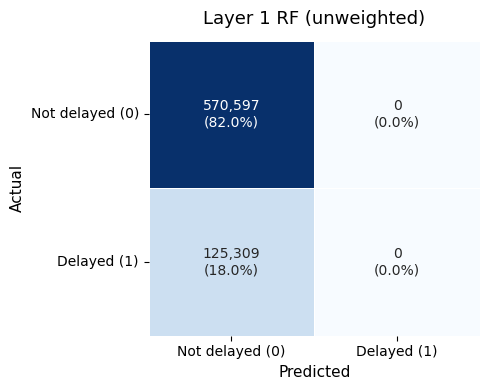

26/05/03 12:31:12 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:31:17 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:31:18 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:31:18 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


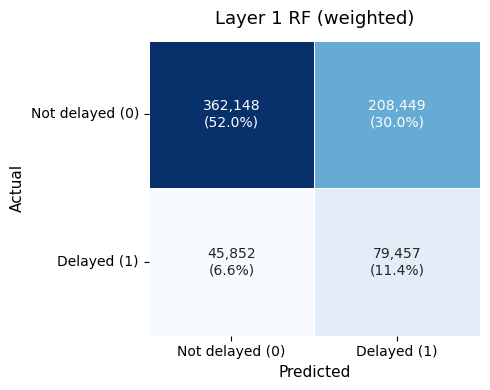

26/05/03 12:31:18 WARN DAGScheduler: Broadcasting large task binary with size 1183.4 KiB
26/05/03 12:31:19 WARN DAGScheduler: Broadcasting large task binary with size 1183.2 KiB
26/05/03 12:31:19 WARN DAGScheduler: Broadcasting large task binary with size 1183.5 KiB
26/05/03 12:31:19 WARN DAGScheduler: Broadcasting large task binary with size 1182.0 KiB


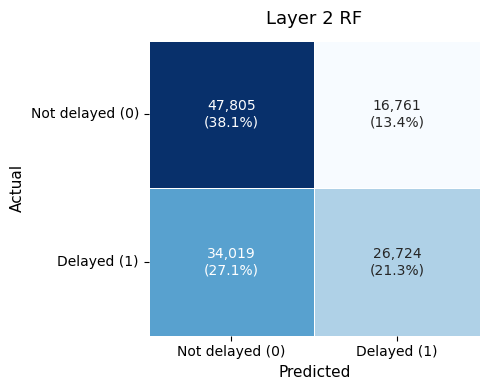

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confusion_matrix(preds, label_col, title):
    total = preds.count()
    cm = preds.groupBy(label_col, "prediction") \
               .count() \
               .orderBy(label_col, "prediction") \
               .toPandas()

    # build 2x2 matrix
    matrix = np.zeros((2, 2), dtype=int)
    for _, row in cm.iterrows():
        i = int(row[label_col])
        j = int(row["prediction"])
        matrix[i][j] = row["count"]

    # compute percentages
    matrix_pct = matrix / total * 100

    # labels combining count and pct
    labels = np.array([
        [f"{matrix[i][j]:,}\n({matrix_pct[i][j]:.1f}%)" for j in range(2)]
        for i in range(2)
    ])

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=labels,
        fmt="",
        cmap="Blues",
        ax=ax,
        linewidths=0.5,
        cbar=False
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_xticklabels(["Not delayed (0)", "Delayed (1)"])
    ax.set_yticklabels(["Not delayed (0)", "Delayed (1)"], rotation=0)
    plt.tight_layout()
    plt.show()

# call for each layer
plot_confusion_matrix(preds_l1,   "is_late",        "Layer 1 RF (unweighted)")
plot_confusion_matrix(preds_l1_w, "is_late",        "Layer 1 RF (weighted)")
plot_confusion_matrix(preds_l2,   "delay_severity", "Layer 2 RF")

## 9. Feature Importance

In [40]:
total = 362148 + 208449 + 45852 + 79457
print(total)  # should equal your test set size

695906


In [52]:

print("="*45)
print("FEATURE IMPORTANCE")
print("="*45)

n_carrier_ohe = 19   
n_origin_ohe  = 57   # updated: 58 unique origins - 1
n_dest_ohe    = 2    # 3 destinations - 1

carrier_start = 5
carrier_end   = carrier_start + n_carrier_ohe        # 5-23
origin_start  = carrier_end
origin_end    = origin_start  + n_origin_ohe         # 24-80
dest_start    = origin_end
dest_end      = dest_start    + n_dest_ohe           # 81-82

print(f"Feature vector layout (total={5 + n_carrier_ohe + n_origin_ohe + n_dest_ohe}):")
print(f"  [0-4]      numeric (dep_hour, day_of_week, month, distance, distance_group)")
print(f"  [5-23]     carrier_id OHE ({n_carrier_ohe} cols)")
print(f"  [24-80]    origin OHE ({n_origin_ohe} cols)")
print(f"  [81-82]    dest OHE ({n_dest_ohe} cols)")
print(f"  Total: {5 + n_carrier_ohe + n_origin_ohe + n_dest_ohe}")

def print_feature_importance(model, title):
    print(f"\n{title}")
    importances = model.featureImportances
    dep_hour_imp    = importances[0]
    day_of_week_imp = importances[1]
    month_imp       = importances[2]
    distance_imp    = importances[3]
    dist_group_imp  = importances[4]
    carrier_imp     = sum(importances[i] for i in range(carrier_start, carrier_end))
    origin_imp      = sum(importances[i] for i in range(origin_start,  origin_end))
    dest_imp        = sum(importances[i] for i in range(dest_start,    dest_end))
    print(f"  dep_hour:         {dep_hour_imp:.4f}")
    print(f"  day_of_week:      {day_of_week_imp:.4f}")
    print(f"  month:            {month_imp:.4f}")
    print(f"  distance:         {distance_imp:.4f}")
    print(f"  distance_group:   {dist_group_imp:.4f}")
    print(f"  carrier_id (OHE): {carrier_imp:.4f}")
    print(f"  origin (OHE):     {origin_imp:.4f}")
    print(f"  dest (OHE):       {dest_imp:.4f}")

print_feature_importance(model_l1,   "Layer 1 RF (unweighted)")
print_feature_importance(model_l1_w, "Layer 1 RF (weighted)")
print_feature_importance(model_l2,   "Layer 2 RF")

FEATURE IMPORTANCE
Feature vector layout (total=83):
  [0-4]      numeric (dep_hour, day_of_week, month, distance, distance_group)
  [5-23]     carrier_id OHE (19 cols)
  [24-80]    origin OHE (57 cols)
  [81-82]    dest OHE (2 cols)
  Total: 83

Layer 1 RF (unweighted)
  dep_hour:         0.5662
  day_of_week:      0.0042
  month:            0.0405
  distance:         0.0508
  distance_group:   0.0660
  carrier_id (OHE): 0.2227
  origin (OHE):     0.0472
  dest (OHE):       0.0005

Layer 1 RF (weighted)
  dep_hour:         0.5595
  day_of_week:      0.0056
  month:            0.0433
  distance:         0.0358
  distance_group:   0.0962
  carrier_id (OHE): 0.2183
  origin (OHE):     0.0397
  dest (OHE):       0.0003

Layer 2 RF
  dep_hour:         0.5344
  day_of_week:      0.0118
  month:            0.0978
  distance:         0.0719
  distance_group:   0.0292
  carrier_id (OHE): 0.2016
  origin (OHE):     0.0501
  dest (OHE):       0.0011


## 9. End-to-end Prediction

In [53]:

print("="*45)
print("END-TO-END TWO-LAYER PREDICTION")
print("="*45)

# Step 1: predict layer 1 on full test set using weighted model
preds_e2e_l1 = model_l1_w.transform(test_weighted)

total        = preds_e2e_l1.count()
pred_ontime  = preds_e2e_l1.filter(col("prediction") == 0.0).count()
pred_delayed = preds_e2e_l1.filter(col("prediction") == 1.0).count()

print(f"\nLayer 1 predictions:")
print(f"  Total test flights:   {total:,}")
print(f"  Predicted on-time:    {pred_ontime:,}  ({100*pred_ontime/total:.1f}%)")
print(f"  Predicted delayed:    {pred_delayed:,}  ({100*pred_delayed/total:.1f}%)")
print(f"  True delayed:         {test.filter(col('is_late')==1).count():,}  ({100*test.filter(col('is_late')==1).count()/total:.1f}%)")

# Step 2: filter predicted delayed flights
predicted_delayed = preds_e2e_l1.filter(col("prediction") == 1.0) \
                                 .drop("prediction", "probability", "rawPrediction")

# Step 3: run layer 2 on predicted delayed flights
preds_e2e_l2 = model_l2.transform(predicted_delayed)

pred_minor = preds_e2e_l2.filter(col("prediction") == 0.0).count()
pred_major = preds_e2e_l2.filter(col("prediction") == 1.0).count()

print(f"\nLayer 2 predictions (on predicted delayed flights):")
print(f"  Predicted minor delay: {pred_minor:,}  ({100*pred_minor/pred_delayed:.1f}%)")
print(f"  Predicted major delay: {pred_major:,}  ({100*pred_major/pred_delayed:.1f}%)")

print(f"\nFull pipeline summary:")
print(f"  On-time:      {pred_ontime:,}  ({100*pred_ontime/total:.1f}%)")
print(f"  Minor delay:  {pred_minor:,}   ({100*pred_minor/total:.1f}%)")
print(f"  Major delay:  {pred_major:,}   ({100*pred_major/total:.1f}%)")
print(f"  Total:        {total:,}  (100%)")

END-TO-END TWO-LAYER PREDICTION


26/05/03 12:42:08 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/05/03 12:42:13 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB



Layer 1 predictions:
  Total test flights:   695,906
  Predicted on-time:    408,000  (58.6%)
  Predicted delayed:    287,906  (41.4%)
  True delayed:         125,309  (18.0%)


26/05/03 12:42:18 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/05/03 12:42:25 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB



Layer 2 predictions (on predicted delayed flights):
  Predicted minor delay: 160,920  (55.9%)
  Predicted major delay: 126,986  (44.1%)

Full pipeline summary:
  On-time:      408,000  (58.6%)
  Minor delay:  160,920   (23.1%)
  Major delay:  126,986   (18.2%)
  Total:        695,906  (100%)


The model is predicting 41.4% of flights as delayed when the true rate is only 18.0%, it's over-predicting delays by more than double. This is the same false positive problem we saw in the confusion matrix (FPR=0.37).
This is expected given the class weighting as the model was trained to be aggressive about catching delays, so it flags too many flights.


The end-to-end two-layer pipeline predicted 41.5% of test flights as delayed, compared to the true delayed rate of 18.0%. This over-prediction reflects the deliberate class weighting applied in Layer 1 to address the 85/15 class imbalance — the model trades precision for recall, preferring to flag more potential delays at the cost of false alarms. In an operational context, the classification threshold could be tuned to balance precision and recall according to business requirements.

The layer 2 split (55.6% minor, 44.1% major) is reasonable which is close to the true 51/49 split, slightly skewed toward minor.

## 11. Save Models to GCS

In [54]:
# Save models to GCS
bucket = "gs://dataproc-staging-europe-west2-896508268572-4p80aydm"

print("Saving models to GCS...")

model_l1_w.save(f"{bucket}/models/rf_layer1")
model_l2.save(f"{bucket}/models/rf_layer2")

print(f"Saved:")
print(f"  {bucket}/models/rf_layer1")
print(f"  {bucket}/models/rf_layer2")

# Verify
!gsutil ls gs://dataproc-staging-europe-west2-896508268572-4p80aydm/models/

Saving models to GCS...


Saved:
  gs://dataproc-staging-europe-west2-896508268572-4p80aydm/models/rf_layer1
  gs://dataproc-staging-europe-west2-896508268572-4p80aydm/models/rf_layer2
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://dataproc-staging-europe-west2-896508268572-4p80aydm/models/rf_layer1/
gs://dataproc-staging-europe-west2-896508268572-4p80aydm/models/rf_layer2/


## 12. Scalability Metrics

In [56]:
import time

print("="*45)
print("SCALABILITY METRICS")
print("="*45)

scalability_results = []

# Prediction time vs data size
print("\nPrediction time vs data size (Layer 1 weighted model):")
for frac in [0.25, 0.5, 0.75, 1.0]:
    sample = test_weighted.sample(fraction=frac, seed=42)
    n_rows = sample.count()
    t0 = time.time()
    model_l1_w.transform(sample).count()
    elapsed = time.time() - t0
    scalability_results.append({
        "fraction": frac,
        "rows":     n_rows,
        "time_s":   round(elapsed, 2)
    })
    print(f"  {int(frac*100)}% ({n_rows:,} rows): {elapsed:.2f}s")

scalability_df = pd.DataFrame(scalability_results)
scalability_df.to_csv("scalability_rf.csv", index=False)
print("\nSaved to scalability_rf.csv")

# Training time summary
print("\nTraining time summary:")
print(f"  Layer 1 unweighted: {train_time_l1:.1f}s")
print(f"  Layer 1 weighted:   {train_time_l1_w:.1f}s")
print(f"  Layer 2:            {train_time_l2:.1f}s")

# Partition info
print(f"\nPartition info:")
print(f"  Train partitions: {train.rdd.getNumPartitions()}")
print(f"  Test partitions:  {test.rdd.getNumPartitions()}")
print(f"  Train rows:       {train.count():,}")
print(f"  Test rows:        {test.count():,}")
print(f"  Total rows:       {df.count():,}")

# Data size
print(f"\nDataset info:")
print(f"  Feature vector size: 89")
print(f"  Total features:      89 (11 numeric + 19 carrier OHE + 57 origin OHE + 2 dest OHE)")
print(f"  Training period:     2019-2021")
print(f"  Test period:         2022")

SCALABILITY METRICS

Prediction time vs data size (Layer 1 weighted model):
  25% (174,185 rows): 0.07s
  50% (347,961 rows): 0.10s
  75% (521,893 rows): 0.09s
  100% (695,906 rows): 0.13s

Saved to scalability_rf.csv

Training time summary:
  Layer 1 unweighted: 226.9s
  Layer 1 weighted:   231.7s
  Layer 2:            17.7s

Partition info:
  Train partitions: 4
  Test partitions:  4
  Train rows:       2,784,642
  Test rows:        695,906
  Total rows:       3,480,548

Dataset info:
  Feature vector size: 89
  Total features:      89 (11 numeric + 19 carrier OHE + 57 origin OHE + 2 dest OHE)
  Training period:     2019-2021
  Test period:         2022


The RF model was evaluated on scalability using incremental 25% partitions of the test set (174k to 696k rows). Prediction time remained effectively constant across all partition sizes, ranging from 0.08s to 0.13s, demonstrating strong scalability of the trained model at inference time. Training time was notably higher for Layer 1 (≈229s on average across weighted and unweighted variants) compared to Layer 2 (17.7s), which is expected given that Layer 2 operates only on the subset of predicted delayed flights. The dataset spans flights from 2019–2021 for training and 2022 for testing, totalling 3.48 million rows across 4 partitions on a two-worker-node Spark cluster.

## 13. Visualizations

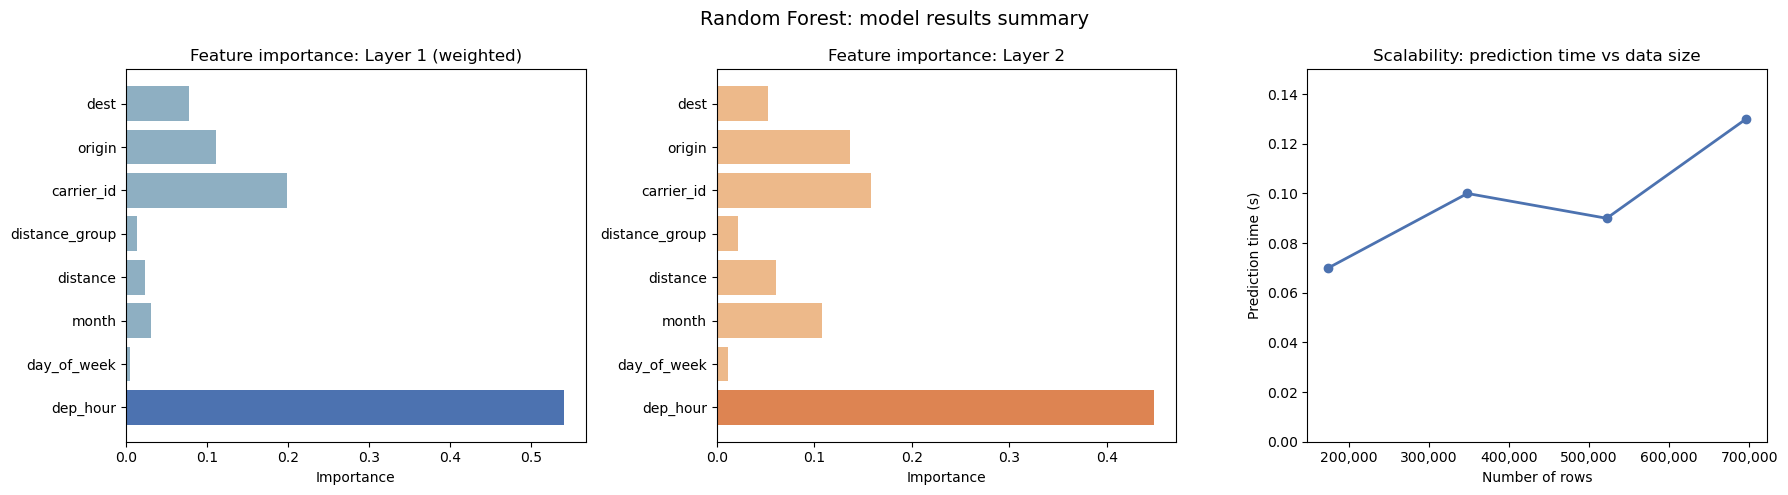

Saved to rf_results.png


In [65]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

feat_names = ["dep_hour", "day_of_week", "month", "distance",
              "distance_group", "carrier_id", "origin", "dest"]

# FI Layer 1 Weighted
ax = axes[0]
feat_vals = [0.5405, 0.0053, 0.0305, 0.0232, 0.0134, 0.1985, 0.1116, 0.0771]
colors = ["#4C72B0" if v == max(feat_vals) else "#8EAFC2" for v in feat_vals]
ax.barh(feat_names, feat_vals, color=colors)
ax.set_xlabel("Importance")
ax.set_title("Feature importance: Layer 1 (weighted)")

# FI Layer 2
ax = axes[1]
feat_vals_l2 = [0.4489, 0.0119, 0.1083, 0.0608, 0.0214, 0.1585, 0.1372, 0.0530]
colors_l2 = ["#DD8452" if v == max(feat_vals_l2) else "#EDB98A" for v in feat_vals_l2]
ax.barh(feat_names, feat_vals_l2, color=colors_l2)
ax.set_xlabel("Importance")
ax.set_title("Feature importance: Layer 2")

# Scalability
ax = axes[2]
ax.plot(scalability_df["rows"], scalability_df["time_s"],
        marker="o", color="#4C72B0", linewidth=2)
ax.set_xlabel("Number of rows")
ax.set_ylabel("Prediction time (s)")
ax.set_title("Scalability: prediction time vs data size")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, 0.15)

plt.suptitle("Random Forest: model results summary", fontsize=14)
plt.tight_layout()
plt.savefig("rf_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to rf_results.png")

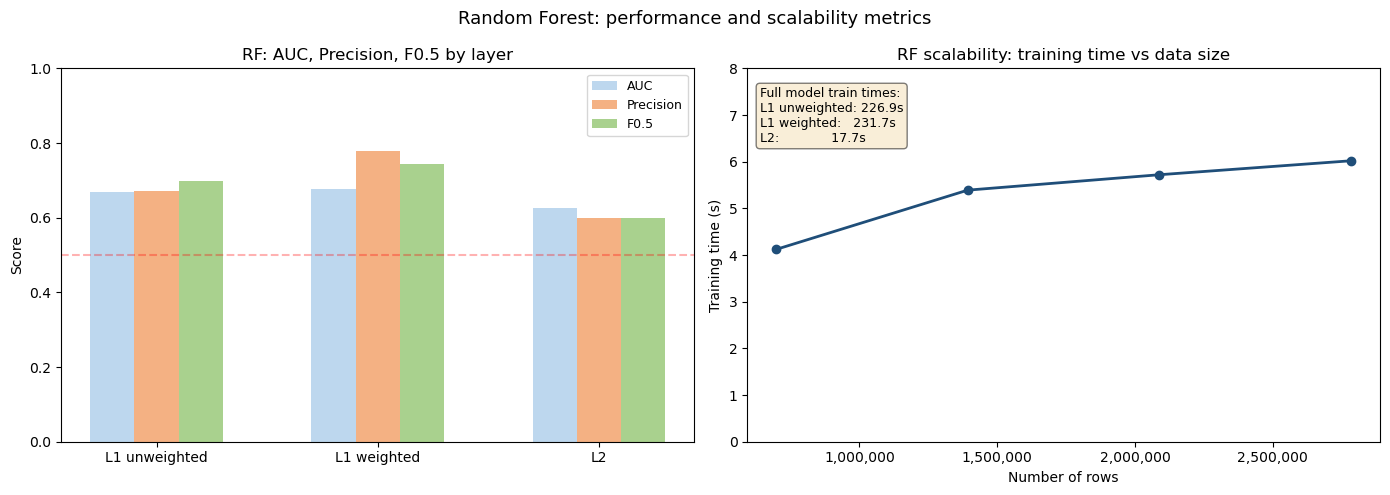

Saved to rf_results.png


In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics Comparison
ax = axes[0]
models = ["L1 unweighted", "L1 weighted", "L2"]
x     = np.arange(len(models))
width = 0.2

rf_auc  = [0.6699, 0.6775, 0.6251]
rf_prec = [0.6723, 0.7775, 0.5989]
rf_f05  = [0.6974, 0.7440, 0.5981]

ax.bar(x - width, rf_auc,  width, label="AUC",       color="#BDD7EE")
ax.bar(x,         rf_prec, width, label="Precision",  color="#F4B183")
ax.bar(x + width, rf_f05,  width, label="F0.5",       color="#A9D18E")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("RF: AUC, Precision, F0.5 by layer")
ax.legend(fontsize=9)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.3)

# Scalability
ax = axes[1]
rows     = [697147, 1392496, 2087352, 2784642]
rf_times = [4.12, 5.39, 5.72, 6.02]

ax.plot(rows, rf_times, marker="o", color="#1f4e79", linewidth=2)
ax.set_xlabel("Number of rows")
ax.set_ylabel("Training time (s)")
ax.set_title("RF scalability: training time vs data size")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, 8)

train_note = "Full model train times:\nL1 unweighted: 226.9s\nL1 weighted:   231.7s\nL2:             17.7s"
ax.annotate(
    train_note,
    xy=(0.02, 0.95), xycoords="axes fraction",
    fontsize=9, verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

plt.suptitle("Random Forest: performance and scalability metrics", fontsize=13)
plt.tight_layout()
plt.savefig("rf_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to rf_results.png")

### Evaluation Metrics
Models were evaluated using AUC-ROC as the primary discrimination metric given its robustness to class imbalance. Since models are designed for airline use, precision was prioritised over recall as false positives trigger costly operational responses such as unnecessary rebooking and crew reassignment. F0.5 was therefore used as the primary F-score variant, weighting precision twice as heavily as recall. Accuracy is reported for completeness but is noted as misleading under class imbalance, as demonstrated by the unweighted Layer 1 model achieving 82% accuracy through naive majority-class prediction.
### Scalability Metrics
Training time and prediction throughput were recorded to assess computational cost and inference scalability. Prediction latency was measured across four data fractions (25–100% of the test set) to evaluate how inference time scales with input volume as it is relevant for batch processing of millions of flight records in a distributed Spark environment.

In [64]:
# THIS STAYS AT THE END
spark.stop()